# Histogram 2CH Analysis
Python conversion of histogram_2CH.m - analyzes phase difference between two channels

In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, hilbert
from scipy.io import loadmat

## Helper Functions

In [64]:
from scipy.signal import butter, sosfiltfilt

def bandpass_filter(data, lowcut, highcut, fs, order=4):
    """Apply IIR bandpass filter using SOS format for numerical stability."""
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    # Use SOS output for better numerical stability with narrow bands
    sos = butter(order, [low, high], btype='band', output='sos')
    return sosfiltfilt(sos, data)

## Load and Configure Data

In [65]:
# File path - update this to your data location
# path = 'C:/Users/baris/OneDrive - California Institute of Technology/CHIC/Projects/DOPA/Data/20221209/meas2/'
path = '../data/fig4_beamforming_20221209_meas2/'
filename = '272deg.csv'

# Load data
M = pd.read_csv(path + filename, header=None).values
M = M[-20001:, :]  # Take last 20k samples (end-20E3:end in MATLAB)

print(f"Data shape: {M.shape}")

Data shape: (20001, 8)


## Set Parameters

In [66]:
# Sampling parameters
N = 1  # undersampling factor
Fsample = 100e6 / N
Frac = 1
start = 0

# Time vector
num_samples = int(len(M) / Frac / N)
t = np.arange(1, num_samples + 1) / Fsample
dt = t[1] - t[0]

dT = dt
Fs = 1 / dT

# Filter parameters
Filter_BW = 5e3  # 2MHz typical
Center_Freq = 1000e3  # 8.57e6, 11.66e6, 9.5e6
BPF_L = Center_Freq - Filter_BW / 2
BPF_H = Center_Freq + Filter_BW / 2

print(f"Sample rate: {Fs/1e6:.2f} MHz")
print(f"Bandpass: {BPF_L/1e3:.1f} - {BPF_H/1e3:.1f} kHz")

Sample rate: 100.00 MHz
Bandpass: 997.5 - 1002.5 kHz


## Extract Signals

In [67]:
# Extract data channels (MATLAB uses 1-based indexing)
end_idx = start + int(len(M) / Frac)
dataIX = M[start:end_idx, 1]  # Column 2 in MATLAB = index 1 in Python
dataIY = M[start:end_idx, 5]  # Column 6 in MATLAB = index 5 in Python

# Recalculate time vector
num_samples = int(len(M) / Frac / N)
t = np.arange(1, num_samples + 1) / Fsample
dt = t[1] - t[0]

SignalX = dataIX
SignalY = dataIY

print(f"SignalX length: {len(SignalX)}")
print(f"SignalY length: {len(SignalY)}")

SignalX length: 20001
SignalY length: 20001


## Apply Bandpass Filter

In [68]:
# Apply bandpass filter
SigIX_Filt = bandpass_filter(SignalX, BPF_L, BPF_H, Fs)
SigIY_Filt = bandpass_filter(SignalY, BPF_L, BPF_H, Fs)

print("Bandpass filtering complete")

Bandpass filtering complete


## Find Peaks

In [69]:
# Find peaks with minimum distance
Nend = 199
min_distance_samples = int(0.5e-6 * Fs)  # 0.5 microseconds in samples

peaks_X, _ = find_peaks(SigIX_Filt, distance=min_distance_samples)
locsX = t[peaks_X[:Nend]] if len(peaks_X) >= Nend else t[peaks_X]

peaks_Y, _ = find_peaks(SigIY_Filt, distance=min_distance_samples)
locsY = t[peaks_Y[:Nend]] if len(peaks_Y) >= Nend else t[peaks_Y]

print(f"Found {len(locsX)} peaks in X, {len(locsY)} peaks in Y")

Found 199 peaks in X, 199 peaks in Y


## Compute FFT

In [70]:
# FFT of raw signal
CHX = SignalX
L = len(CHX)
Y = np.fft.fft(CHX)
P2 = np.abs(Y / L)
P1 = P2[:L//2 + 1]
P1[1:-1] = 2 * P1[1:-1]
P1_CHX = P1

# FFT of filtered signal
CHX_filt = SigIX_Filt
L = len(CHX_filt)
Y = np.fft.fft(CHX_filt)
P2 = np.abs(Y / L)
P1 = P2[:L//2 + 1]
P1[1:-1] = 2 * P1[1:-1]
P1_CHX_filt = P1

# Frequency vector
f = Fs * np.arange(0, L//2 + 1) / L

Raw FFT - min: -61.3 dB, max: -1.8 dB
Filtered FFT - min: -55.7 dB, max: -13.3 dB
Filtered signal max value: 0.129037


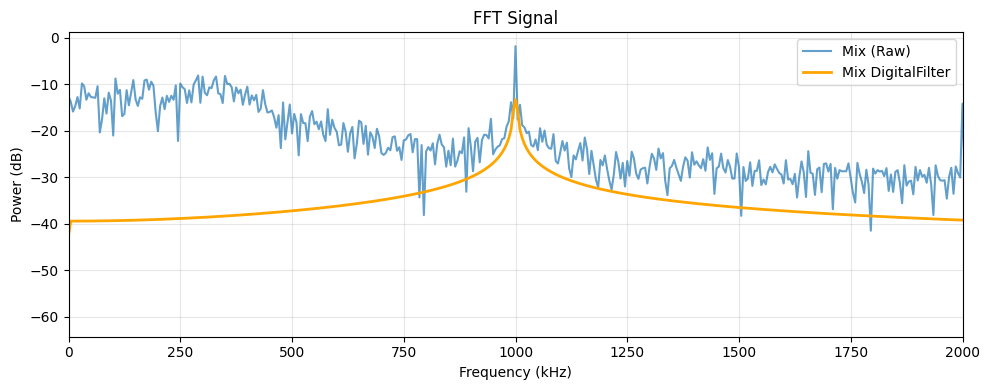

In [83]:
# Plot FFT
fig, ax = plt.subplots(figsize=(10, 4))

# Convert to dB
P1_CHX_dB = 10 * np.log10(P1_CHX + 1e-12)
P1_CHX_filt_dB = 10 * np.log10(P1_CHX_filt + 1e-12)

# Debug: check if filtered signal has valid data
print(f"Raw FFT - min: {P1_CHX_dB.min():.1f} dB, max: {P1_CHX_dB.max():.1f} dB")
print(f"Filtered FFT - min: {P1_CHX_filt_dB.min():.1f} dB, max: {P1_CHX_filt_dB.max():.1f} dB")
print(f"Filtered signal max value: {np.max(np.abs(SigIX_Filt)):.6f}")

# Plot both signals
ax.plot(f / 1e3, P1_CHX_dB, label='Mix (Raw)', alpha=0.7)
ax.plot(f / 1e3, P1_CHX_filt_dB, label='Mix DigitalFilter', color='orange', linewidth=2)
ax.set_xlabel('Frequency (kHz)')
ax.set_ylabel('Power (dB)')
ax.set_xlim([0, 2000])
ax.legend()
ax.set_title('FFT Signal')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Hilbert Transform and Phase Extraction

In [84]:
# Hilbert transform
HT_CHX = hilbert(SigIX_Filt)
HT_CHY = hilbert(SigIY_Filt)

# Amplitude squared
amp2_X = np.imag(HT_CHX)**2 + np.real(HT_CHX)**2
amp2_Y = np.imag(HT_CHY)**2 + np.real(HT_CHY)**2

# Phase extraction and unwrapping
phase_CHX = np.arctan2(np.imag(HT_CHX), np.real(HT_CHX))
phase_CHX = np.unwrap(phase_CHX)
phase_CHY = np.arctan2(np.imag(HT_CHY), np.real(HT_CHY))
phase_CHY = np.unwrap(phase_CHY)

print("Hilbert transform and phase extraction complete")

Hilbert transform and phase extraction complete


## Trim Edge Effects

In [89]:
# Create mask for trimming edge effects (50 us from edges)
t_max = np.max(t)
trim_mask = (t >= 50e-6) & (t <= (t_max - 50e-6))

# Trim amplitude data
amp2_X_trimmed = amp2_X[trim_mask]
amp2_Y_trimmed = amp2_Y[trim_mask]

## Calculate Phase Difference

In [90]:
# Phase difference calculation
phiO = 0
PhaseDiff = np.mod(phase_CHX - phase_CHY + phiO, 2 * np.pi) - phiO

# Trim phase difference data
PhaseDiff_trimmed = PhaseDiff[trim_mask]
t2 = t[trim_mask]

print(f"Phase difference samples: {len(PhaseDiff_trimmed)}")

Phase difference samples: 10002


## Histogram

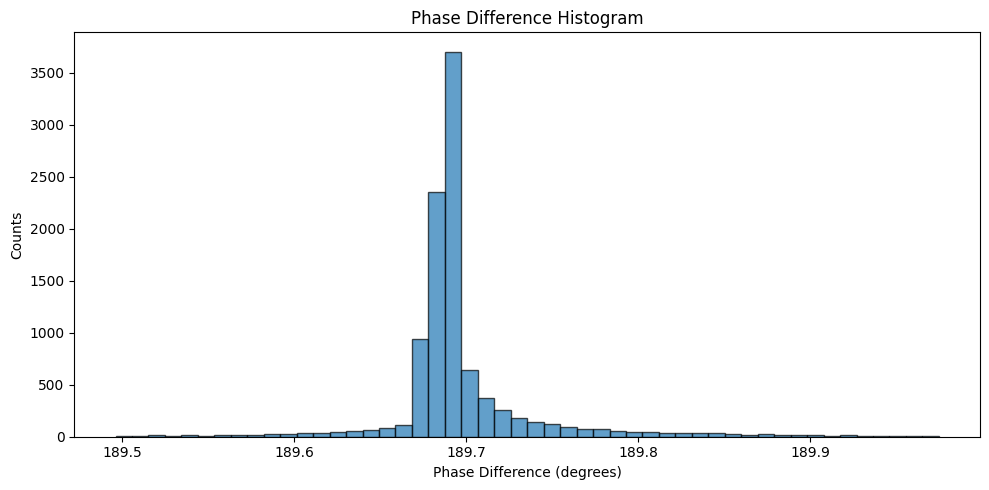

In [91]:
# Convert phase difference to degrees
phase_deg = PhaseDiff_trimmed * 180 / np.pi

# Plot histogram
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(phase_deg, bins=50, edgecolor='black', alpha=0.7)
ax.set_xlabel('Phase Difference (degrees)')
ax.set_ylabel('Counts')
ax.set_title('Phase Difference Histogram')
plt.tight_layout()
plt.show()

## Statistics

In [92]:
# Calculate and print statistics
median_val = np.median(phase_deg)
mean_val = np.mean(phase_deg)
std_val = np.std(phase_deg)

print(f"Median = {median_val:.2f}")
print(f"Mean = {mean_val:.2f}")
print(f"Std = {std_val:.2f}")

if std_val > 10:
    print("BAD DATA")

Median = 189.69
Mean = 189.70
Std = 0.04
